In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.stats import norm

# Usiamo comment='#' per ignorare tutte le righe di intestazione
# sep='\s+' gestisce correttamente gli spazi variabili tra le colonne
df = pd.read_csv('E_zcat.dat', sep='\s+', comment='#', header=None)

# La quarta colonna (Redshift) ha indice 3
# Creiamo un filtro per escludere gli z = 0
df_filtrato = df[df[3] != 0]

# Se vuoi vedere solo la colonna dei redshift filtrati
print(df_filtrato[3])


0       0.6784
2       0.7190
3       0.8322
4       0.6790
5       0.4116
         ...  
3104    0.1834
3106    0.4415
3107    0.4419
3108    0.4362
3109    0.4274
Name: 3, Length: 2861, dtype: float64


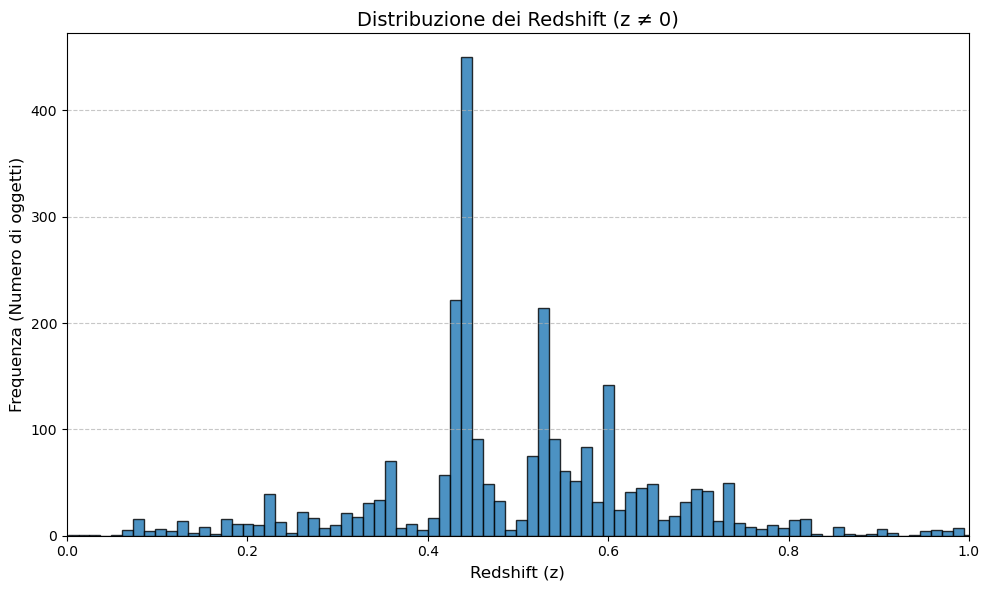

In [47]:
# 3. Crea l'istogramma
plt.figure(figsize=(10, 6))

plt.hist(df_filtrato[3], bins=500, color='#1f77b4', edgecolor='black', alpha=0.8)

# 4. Personalizza l'estetica del grafico
plt.title('Distribuzione dei Redshift (z ≠ 0)', fontsize=14)
plt.xlabel('Redshift (z)', fontsize=12)
plt.xlim(0, 1)  # Aggiungiamo un piccolo margine ai limiti
plt.ylabel('Frequenza (Numero di oggetti)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 5. Visualizza il grafico a schermo 
# (Se vuoi salvarlo come immagine, usa plt.savefig('nome_file.png') al posto di show)
plt.show()

# 6. (Opzionale) Salva i dati puliti in un nuovo file CSV
df_filtrato[3].to_csv('redshift_filtrati.csv', index=False, header=['Redshift'])

Numero di oggetti nell'intervallo: 721


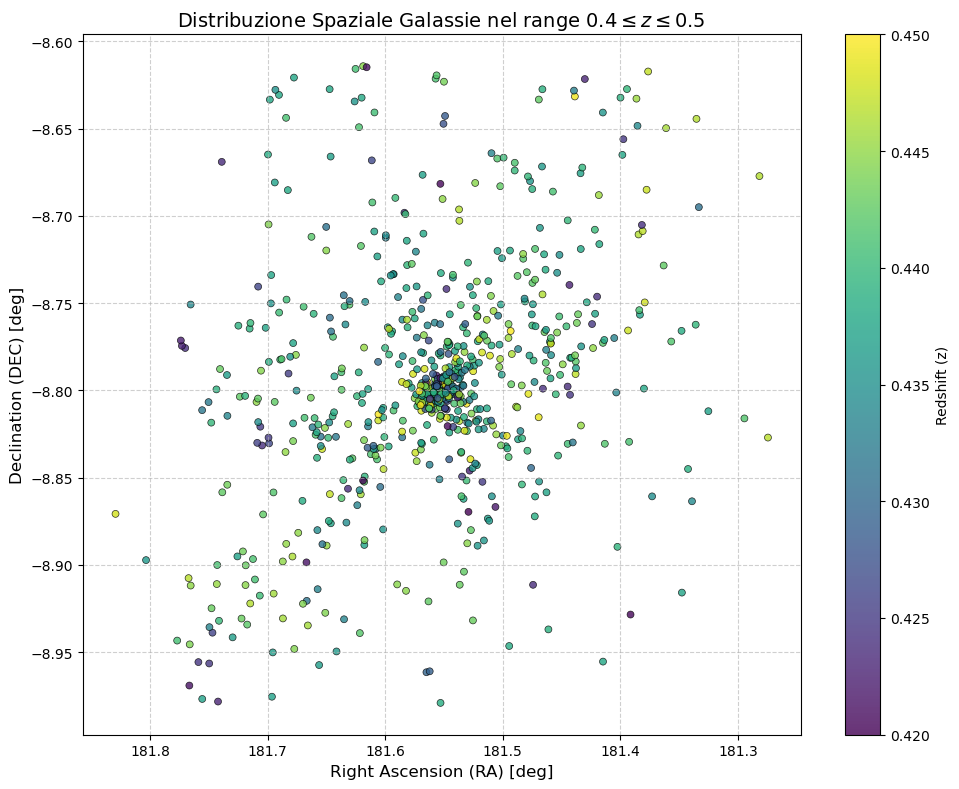

In [25]:
df_intervallo = df[df[3].between(0.42, 0.45)]
#stampo quanti oggetti ci sono in questo intervallo
print(f"Numero di oggetti nell'intervallo: {len(df_intervallo)}")

# 3. Estraiamo RA (indice 1), DEC (indice 2) e Redshift (indice 3)
ra = df_intervallo[1]
dec = df_intervallo[2]
z_vals = df_intervallo[3]

z_max = df_intervallo[3].max()
z_min = df_intervallo[3].min()

# 4. Creiamo il grafico a dispersione (scatter plot)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(ra, dec, s=25, c=z_vals, cmap='viridis', alpha=0.8, edgecolor='k', linewidth=0.5)

# 5. Aggiungiamo barra dei colori e dettagli
plt.colorbar(scatter, label='Redshift (z)')
plt.xlabel('Right Ascension (RA) [deg]', fontsize=12)
plt.ylabel('Declination (DEC) [deg]', fontsize=12)
plt.title('Distribuzione Spaziale Galassie nel range $0.4 \leq z \leq 0.5$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.gca().invert_xaxis()
plt.tight_layout()

# 7. Mostriamo il grafico
plt.show()


In [28]:
def log_prior(theta):
    z0, sigma_z, f = theta
    if z_min < z0 < z_max and 0.0 < sigma_z < 0.1 and 0.0 < f < 1.0:
        return 0.0 
    return -np.inf

def log_likelihood(theta, z_obs):
    z0, sigma_z, f = theta
    uniforme = 1.0/(z_max - z_min)
    model = f * norm.pdf(z_obs, loc=z0, scale=sigma_z) + (1 - f) * uniforme
    return np.sum(np.log(model))

def log_posterior(theta, z_obs):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z_obs)

Inizializzazione dei camminatori MCMC...
Lancio MCMC con 10000 step per 32 camminatori...


100%|██████████| 10000/10000 [00:22<00:00, 442.90it/s]


Campionamento completato.


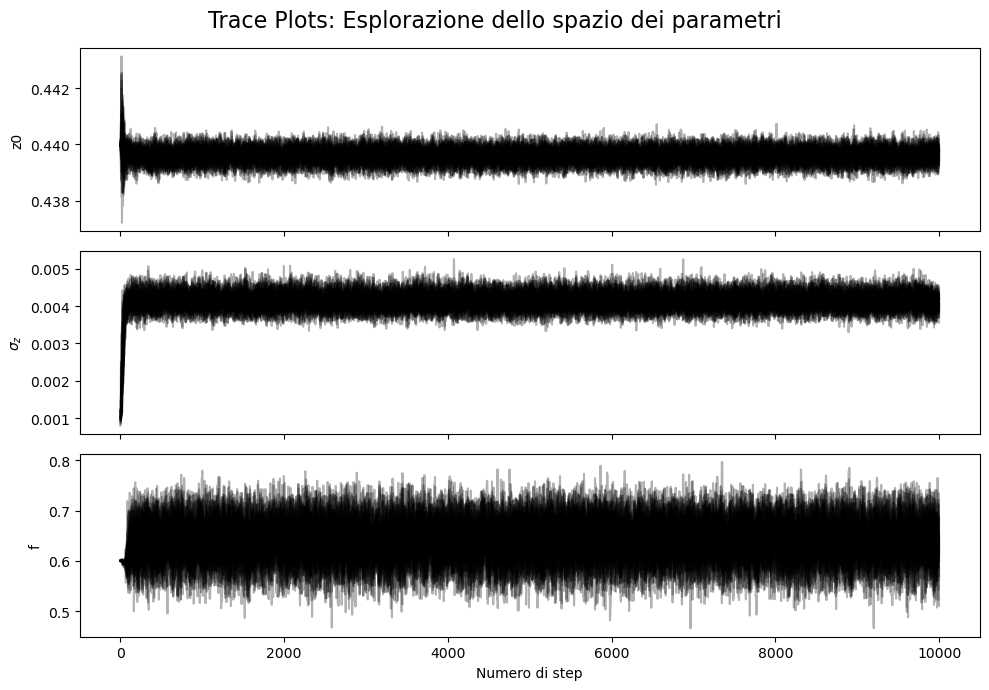

In [31]:
print("Inizializzazione dei camminatori MCMC...")

n_dim = 3         # Numero di parametri (H_0, Omega_m)
n_walkers = 32    # Numero di camminatori
n_steps = 10000    # Passi per ogni camminatore

stima_iniziale = [0.44, 0.001, 0.6]  # [z0_guess, sigma_z_guess, f_guess]
#attenzine, scegliere condizioni iniziali sbagliate porta i camminatori a perdersi

pos_iniziali = stima_iniziale + 1e-4 * np.random.randn(n_walkers, n_dim)


#lancio emcee
print(f"Lancio MCMC con {n_steps} step per {n_walkers} camminatori...")
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(df_intervallo[3].values,))

#barra di caricamento
sampler.run_mcmc(pos_iniziali, n_steps, progress=True)
print("Campionamento completato.")

samples_walkers = sampler.get_chain()
nomi_params = ["z0", r"$\sigma_z$", "f"]

fig, axes = plt.subplots(n_dim, 1, figsize=(10, 7), sharex=True)

for i in range(n_dim):
    ax = axes[i]
    # Plottiamo le traiettorie di tutti i camminatori per il parametro i-esimo
    ax.plot(samples_walkers[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(nomi_params[i])
    
axes[-1].set_xlabel("Numero di step")
plt.suptitle("Trace Plots: Esplorazione dello spazio dei parametri", fontsize=16)
plt.tight_layout()
plt.show()

Estrazione dei campioni e rimozione del burn-in...
Campioni validi estratti: 304000


### Risultati dell'Inferenza (Mediana e $1\sigma$):

**$z_0$**: $ 0.44_{-0.00}^{+0.00} $

**$\sigma_z$**: $ 0.004_{-0.000}^{+0.000} $

**$f$**: $ 0.64_{-0.08}^{+0.07} $


Generazione del Corner Plot...


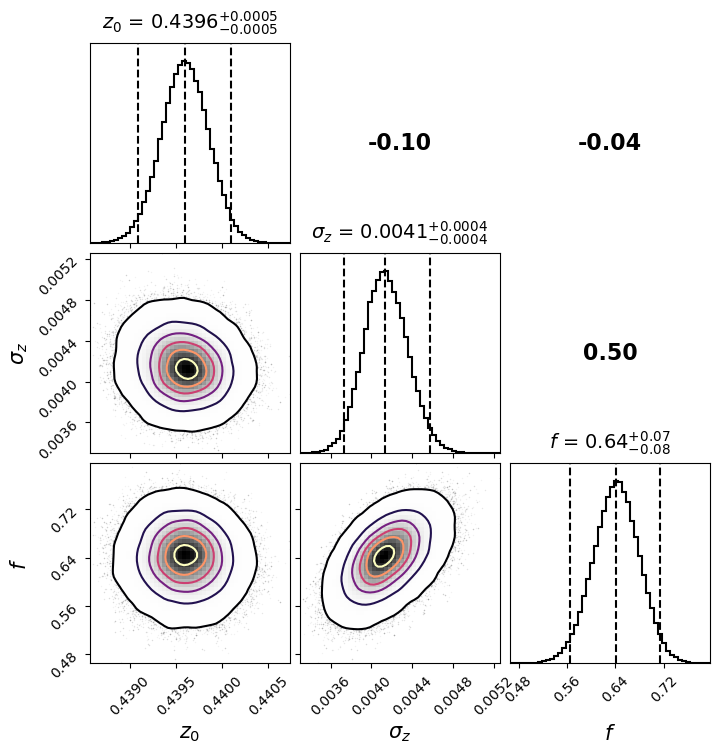

In [44]:
import corner
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Estrazione dei campioni e rimozione del burn-in...")

# Togliamo i primi 500 step (burn-in).
burn_in = 500
samples_analisis = sampler.get_chain(discard=burn_in, flat=True)

nomi_params = [r"$z_0$", r"$\sigma_z$", r"$f$"]
n_dim = len(nomi_params)
samples_df = pd.DataFrame(samples_analisis, columns=nomi_params)

print(f"Campioni validi estratti: {len(samples_df)}")

# === STAMPA DEI RISULTATI NUMERICI ===
risultati = []
for i, col in enumerate(nomi_params):
    q16, q50, q84 = np.percentile(samples_df[col], [2.5, 50, 97.5])
    err_minus = q50 - q16
    err_plus = q84 - q50
    prec = ".3f" if col == r"$\sigma_z$" else ".2f"
    risultati.append(f"**{col}**: $ {q50:{prec}}_{{-{err_minus:{prec}}}}^{{+{err_plus:{prec}}}} $")

display(Markdown("### Risultati dell'Inferenza (Mediana e $1\sigma$):"))
for res in risultati:
    display(Markdown(res))

print("\nGenerazione del Corner Plot...")

corr_matrix = samples_df.corr(method='pearson').values

# ECCO LA MODIFICA: Più valori = più curve nel grafico 2D. 
# Ho inserito 6 livelli che racchiudono il 10%, 30%, 50%, 68.3%, 86.4% e 98.8% dei dati.
livelli_2d = [0.10, 0.30, 0.50, 0.683, 0.864, 0.988]

# Generazione del plot
fig = corner.corner(
    samples_analisis,
    labels=nomi_params,
    bins=50,
    quantiles=[0.025, 0.5, 0.975], 
    show_titles=False, # <-- MODIFICA: Disabilita i titoli automatici di corner
    label_kwargs={"fontsize": 15},
    
    color="black", 
    fill_contours=False,
    contour_kwargs={"cmap": "magma", "colors": None, "linewidths": 1.5},
    
    plot_datapoints=True,
    data_kwargs={"alpha": 0.1, "color": "gray", "ms": 1.0},
    
    hist_kwargs={"linewidth": 1.5, "histtype": "step"},
    smooth=1.2,
    levels=livelli_2d
)

axes = np.array(fig.axes).reshape((n_dim, n_dim))

# === AGGIUNTA DEI TITOLI PERSONALIZZATI SULLA DIAGONALE ===
for i, col in enumerate(nomi_params):
    ax = axes[i, i] # Prende il grafico 1D sulla diagonale
    
    # Ricalcoliamo i quantili per il titolo
    q16, q50, q84 = np.percentile(samples_df[col], [2.5, 50, 97.5])
    err_minus = q50 - q16
    err_plus = q84 - q50
    
    # Scegliamo la precisione: 3 per sigma_z, 2 per gli altri
    if col == r"$\sigma_z$": prec = ".4f" 
    if col == r"$z_0$": prec = ".4f" 
    if col == r"$f$": prec = ".2f"
    
    # Creiamo la stringa in formato LaTeX per il titolo
    titolo = f"{col} = ${q50:{prec}}_{{-{err_minus:{prec}}}}^{{+{err_plus:{prec}}}}$"
    ax.set_title(titolo, fontsize=14, pad=10)

# === AGGIUNTA DEI COEFFICIENTI DI PEARSON NEL TRIANGOLO SUPERIORE ===
for i in range(n_dim):
    for j in range(n_dim):
        ax = axes[i, j]
        
        if j > i:
            ax.set_visible(True)
            ax.set_frame_on(False) 
            ax.set_xticks([])      
            ax.set_yticks([])      
            
            corr_val = corr_matrix[i, j]
            
            ax.text(0.5, 0.5, f"{corr_val:.2f}",
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=16,
                    fontweight='bold',
                    transform=ax.transAxes)

plt.show()

z0_mcmc, sigma_z_mcmc, f_mcmc = np.percentile(samples_analisis, 50, axis=0)

In [38]:

limite_sigma = 3 * sigma_z_mcmc

# Una galassia è membro se la distanza assoluta del suo redshift dal centro (z0) è minore di 3 sigma
df_intervallo["membro_cluster"] = np.abs(df_intervallo[3] - z0_mcmc) <= limite_sigma

# Creo il dataset pulito
df_cluster = df_intervallo[df_intervallo["membro_cluster"]].copy()

# Stampo i risultati
galassie_totali = len(df_intervallo)
galassie_ammasso = len(df_cluster)
print(f"--- FILTRAGGIO 3-SIGMA COMPLETATO ---")
print(f"Galassie totali iniziali : {galassie_totali}")
print(f"Galassie dell'ammasso    : {galassie_ammasso}")
print(f"Background scartato      : {galassie_totali - galassie_ammasso}")

--- FILTRAGGIO 3-SIGMA COMPLETATO ---
Galassie totali iniziali : 721
Galassie dell'ammasso    : 662
Background scartato      : 59


/var/folders/tw/w5d25s8d0hs0jfpds08cmlnh0000gn/T/ipykernel_3654/2559395165.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_intervallo["membro_cluster"] = np.abs(df_intervallo[3] - z0_mcmc) <= limite_sigma


In [42]:
#calcolo distanza
from scipy.integrate import quad

def E(z, Omega_m):
    return 1 / np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))

def D_L(z, H_0, Omega_m):
    """Distanza di luminosità in Mpc."""
    c = 299792.458 # Velocità della luce in km/s
    integrale = quad(E, 0, z, args=(Omega_m,))[0]
    return (c / H_0) * (1 + z) * integrale

D_L_cluster = D_L(z0_mcmc, 70.0, 0.3)

print(f"Distanza di luminosità dell'ammasso: {D_L_cluster:.2f} Mpc")

D_cluster = D_L_cluster / (1 + z0_mcmc)**2

print(f"Distanza comovente dell'ammasso: {D_cluster:.2f} Mpc")

sigma_v = 299792.458/(1 + z0_mcmc) * sigma_z_mcmc

def massa_viriale(sigma_v, r_vir):
    G = 4.30091e-6  # kpc (km/s)^2 / M_sun
    return (3 * sigma_v**2 * r_vir) / G

r_vir = 2*1e3  # kpc
massa_viriale = massa_viriale(sigma_v, r_vir)
print(f"Stima della massa viriale dell'ammasso: {massa_viriale:.2e} M_sun")

Distanza di luminosità dell'ammasso: 2429.16 Mpc
Distanza comovente dell'ammasso: 1172.12 Mpc
Stima della massa viriale dell'ammasso: 1.04e+15 M_sun
